In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [13]:
df=pd.read_csv("abc.csv")

In [14]:
df.head(5)

,Height (cm),Weight (kg)
0,162,58
1,175,72
2,180,85
3,155,50
4,170,68


Text(0, 0.5, 'height')

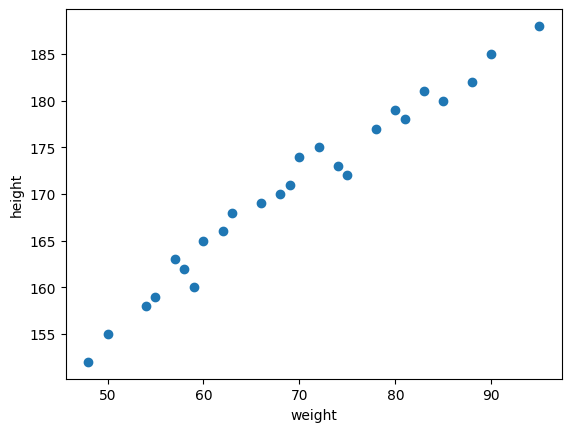

In [16]:
#scatter plt
plt.scatter(df["Weight (kg)"],df["Height (cm)"])
plt.xlabel("weight")
plt.ylabel("height")

In [17]:
df.corr()

,Height (cm),Weight (kg)
Height (cm),1.000000,0.984845
Weight (kg),0.984845,1.000000


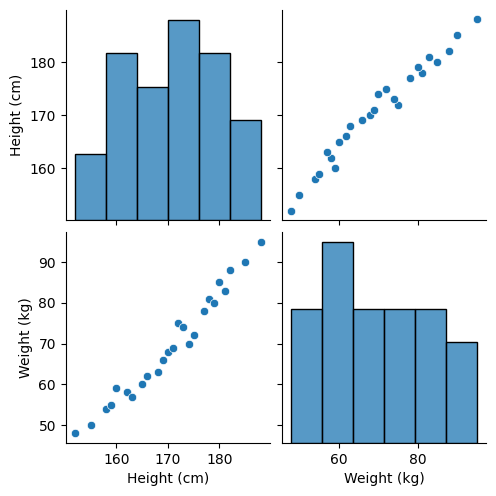

In [19]:
import seaborn as sns
sns.pairplot(df)

In [21]:
X=df[["Weight (kg)"]]
Y=df["Height (cm)"]
type(X)

pandas.core.frame.DataFrame

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [32]:
X_test=scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)

In [35]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
print(regression.coef_)
print(regression.intercept_)

[9.26746016]
169.77777777777777


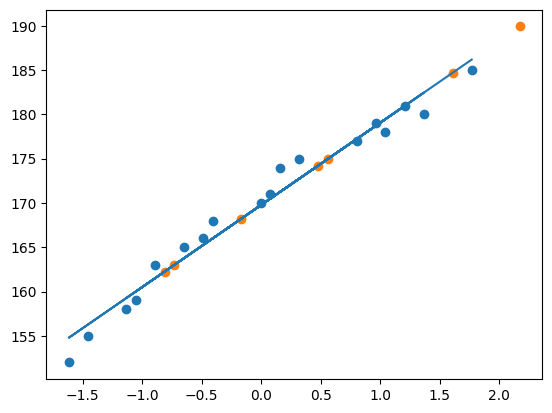

In [61]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train))
plt.scatter(X_test,regression.predict(X_test))

In [46]:
y_pred=regression.predict(X_test)
y_pred

array([174.96857745, 189.91808051, 162.26149985, 174.2211023 ,
       184.68575444, 163.008975  , 168.24130107])

In [55]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [62]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4.413398499015401
1.8318126407274025
2.1008090105993458


In [ ]:
from sklearn.metrics import r2_score

score=r2_score(Y_test,y_pred)
print(score)

0.9493069558247176


In [65]:
import statsmodels.api as sm

In [66]:
model=sm.OLS(Y_train,X_train).fit()

In [67]:
prediction=model.predict(X_test)
print(prediction)

[ 5.19079967 20.14030274 -7.51627793  4.44332452 14.90797666 -6.76880278
 -1.5364767 ]
